
# Variant Score Comparison (limb vs neuron)

对比 `/home1/xyf/data/openspliceai_tissue_data/variant/limb_400.vcf` 和 `/home1/xyf/data/openspliceai_tissue_data/variant/neuron_400.vcf` 的打分差异。


In [3]:

from pathlib import Path
import pandas as pd
import pysam

limb_vcf = Path('/home1/xyf/data/openspliceai_tissue_data/variant/limb_400.vcf')
neuron_vcf = Path('/home1/xyf/data/openspliceai_tissue_data/variant/neuron_400.vcf')


In [4]:

# 读取 VCF，提取染色体/坐标/REF/ALT 以及数值型 INFO 字段
def load_vcf(path: Path) -> pd.DataFrame:
    vf = pysam.VariantFile(path)
    records = []
    for rec in vf.fetch():
        row = {
            'CHROM': str(rec.chrom),
            'POS': int(rec.pos),
            'REF': str(rec.ref),
            'ALT': str(rec.alts[0]) if rec.alts else ''
        }
        for key, val in rec.info.items():
            if isinstance(val, (int, float)):
                row[key] = float(val)
            elif isinstance(val, (tuple, list)) and len(val) == 1 and isinstance(val[0], (int, float)):
                row[key] = float(val[0])
        records.append(row)
    return pd.DataFrame(records)


In [5]:

limb_df = load_vcf(limb_vcf)
neuron_df = load_vcf(neuron_vcf)
print(limb_df.shape, neuron_df.shape)
limb_df.head()


(4882, 4) (4882, 4)


,CHROM,POS,REF,ALT
0,chr18,203143,C,T
1,chr5,205713,C,A
2,chr18,216552,G,T
3,chr11,233081,T,C
4,chr16,260008,GGGCC,G


In [9]:

limb_df

,CHROM,POS,REF,ALT
0,chr18,203143,C,T
1,chr5,205713,C,A
2,chr18,216552,G,T
3,chr11,233081,T,C
4,chr16,260008,GGGCC,G
...,...,...,...,...
4877,chr1,248061474,C,T
4878,chr1,248324182,AG,A
4879,chr1,248441496,C,CCTTAG
4880,chr1,248811941,C,T


In [ ]:
!pwd
# 如需切换目录，请使用：
# %cd /home1/xyf/project/github/OpenSpliceAI/T

/home1/xyf/project/github/OpenSpliceAI/T


In [ ]:
!pwd
# 如需切换目录，请使用：
# %cd /home1/xyf/project/github/OpenSpliceAI/T

/home1/xyf/project/github/OpenSpliceAI/T


In [6]:

# 对齐列并合并
score_cols = sorted(set(limb_df.columns) | set(neuron_df.columns))
for df in (limb_df, neuron_df):
    for c in score_cols:
        if c not in df.columns:
            df[c] = pd.NA

merge_cols = ['CHROM','POS','REF','ALT']
limb_df = limb_df[merge_cols + [c for c in score_cols if c not in merge_cols]]
neuron_df = neuron_df[merge_cols + [c for c in score_cols if c not in merge_cols]]

merged = limb_df.merge(neuron_df, on=merge_cols, suffixes=('_limb', '_neuron'))
print(f"共有重叠变异 {len(merged):,} 条")
merged.head()


共有重叠变异 4,882 条


,CHROM,POS,REF,ALT
0,chr18,203143,C,T
1,chr5,205713,C,A
2,chr18,216552,G,T
3,chr11,233081,T,C
4,chr16,260008,GGGCC,G


In [7]:

# 计算各打分字段的差异（neuron - limb）
diff_stats = {}
for col in [c for c in merged.columns if c.endswith('_limb')]:
    base = col[:-5]
    limb_col = f"{base}_limb"
    neuron_col = f"{base}_neuron"
    if limb_col not in merged or neuron_col not in merged:
        continue
    if merged[limb_col].dtype.kind not in 'fi' or merged[neuron_col].dtype.kind not in 'fi':
        continue
    diff = merged[neuron_col] - merged[limb_col]
    diff_stats[base] = {
        'count': diff.notna().sum(),
        'mean_diff': diff.mean(),
        'median_diff': diff.median(),
        'min_diff': diff.min(),
        'max_diff': diff.max(),
    }

diff_df = pd.DataFrame(diff_stats).T
print(diff_df)


Empty DataFrame
Columns: []
Index: []


In [8]:

# 导出合并表格（可选）
out_path = Path('T/limb_neuron_merged.parquet')
out_path.parent.mkdir(parents=True, exist_ok=True)
merged.to_parquet(out_path, index=False)
print(f"已保存合并结果: {out_path}")


ArrowTypeError: ('Did not pass numpy.dtype object', 'Conversion failed for column POS with type int64')

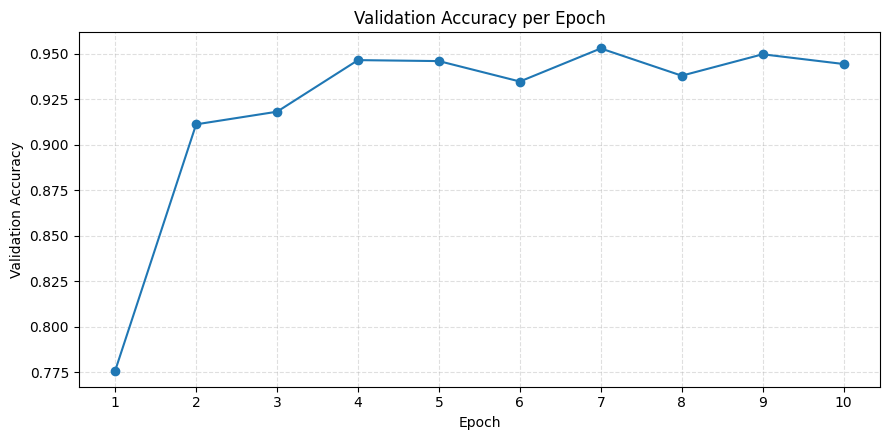

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt

accuracy_path = Path(
    "/home1/xyf/data/openspliceai_tissue_data/train_model/reference_model_400/SpliceAI_reference_model_400_10000_0_rs42/0/LOG/VAL/accuracy.txt"
)

with accuracy_path.open() as f:
    accuracies = [float(line.strip()) for line in f if line.strip()]

epochs = list(range(1, len(accuracies) + 1))

plt.figure(figsize=(9, 4.5))
plt.plot(epochs, accuracies, marker="o", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Epoch")
plt.xticks(range(1, len(epochs) + 1, max(1, len(epochs) // 10)))
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
